## import libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np

import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error, make_scorer
from sklearn.preprocessing import StandardScaler

from xgboost import XGBRegressor
import optuna
import plotly

import torch
from torch.utils.data import DataLoader

from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.core.module import LightningModule
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

import datetime as dt
from datetime import date

import holidays

import torch
import gc

import optuna

import os
import re




## define functions

In [2]:
def metric_results(y_train, y_train_pred, y_test, y_test_pred, ndigits=2, target_unit="target"):
    from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error
    
    mean_load_test = y_test.mean()
    mse_test = mean_squared_error(y_test, y_test_pred)
    mae_test = mean_absolute_error(y_test, y_test_pred)
    rel_mae_test  = mae_test / mean_load_test * 100
    rmse_test = root_mean_squared_error(y_test, y_test_pred)
    rel_rmse_test = rmse_test / mean_load_test * 100
    r2_test = r2_score(y_test, y_test_pred) * 100
   
    mean_load_train = y_train.mean()
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    rel_mae_train  = mae_train / mean_load_train * 100
    rmse_train = root_mean_squared_error(y_train, y_train_pred)
    rel_rmse_train = rmse_train / mean_load_train * 100
    r2_train = r2_score(y_train, y_train_pred) * 100   


    table = pd.DataFrame(
    [
        [">70%", "0", "0", "0%", "0%"],
        ["%", target_unit, target_unit, "%", "%"],
        [r2_train, rmse_train, mae_train, rel_rmse_train, rel_mae_train],
        [r2_test, rmse_test, mae_test, rel_rmse_test, rel_mae_test],
        [r2_train-r2_test, rmse_train-rmse_test, mae_train-mae_test, rel_rmse_train-rel_rmse_test, rel_mae_train-rel_mae_test]
    ],
    index=["optimal", "unit", "train", "test", "diff"],
    columns=["R²", "RMSE", "MAE", "relRMSE", "relMAE"]
    )

    num_rows = ["train", "test", "diff"]                    # numerische Zeilen nochmal zu float umwandeln
    table.loc[num_rows] = (
        table.loc[num_rows].astype(float).round(ndigits)
    )

    return table


def reset_GPU():
    # delete model and tensors 
    del model
    del data
    del loss

    # run python garbage collector
    gc.collect()

    # clear GPU cache
    torch.cuda.empty_cache()

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    return np.mean(np.abs(y_true - y_pred) / (denom + eps)) * 100.0


def scale_features(df, feature_list, no_scale):
    
    # Features die NICHT skaliert werden sollen, werden außerhalb aufgelistet!!! -> no_scale
    
    # alle Features, die skaliert werden sollen
    scale_cols = [c for c in feature_list if c not in no_scale]

    scaler = StandardScaler()

    df_scaled = df.copy()

    df_scaled[scale_cols] = scaler.fit_transform(df_scaled[scale_cols])

    return df_scaled, scaler, scale_cols

import torch

class WarmupLR(torch.optim.lr_scheduler.LambdaLR):
    def __init__(self, optimizer, warmup_steps, last_epoch=-1):
        self.warmup_steps = max(1, int(warmup_steps))
        super().__init__(optimizer, lr_lambda=self._warmup_lambda, last_epoch=last_epoch)

    def _warmup_lambda(self, step: int):
        if step < self.warmup_steps:
            return float(step) / float(self.warmup_steps)   # linear warmup
        return 1.0

## 1. - load datasets

In [4]:
df = pd.read_csv(r"dataset\2 - data second model\load_and_weather_2024-01-01_2026-02-28_cleaned.csv",
                # index_col=0,      # date_time should be a column for TFT model and not the index
                parse_dates=True
                )
df.head(5)

,date_time,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,temp_lag1h,temp_lag3h,temp_lag6h,temp_lag24h,temp_lag48h,rolling_temp_3h,rolling_temp_6h,rolling_temp_12h,wet_bulb_lag1h,wet_bulb_lag3h,wet_bulb_lag6h,wet_bulb_lag24h,wet_bulb_lag48h,rolling_wet_bulb_3h,rolling_wet_bulb_6h,rolling_wet_bulb_12h,radiation_lag1h,radiation_lag3h,radiation_lag6h,radiation_lag24h,radiation_lag48h,rolling_radiation_3h,rolling_radiation_6h,rolling_radiation_12h,precip_lag1h,precip_lag3h,precip_lag6h,precip_lag24h,precip_lag48h,rolling_precip_3h,rolling_precip_6h,rolling_precip_12h,rel_humidity_lag1h,rel_humidity_lag3h,rel_humidity_lag6h,rel_humidity_lag24h,rel_humidity_lag48h,rolling_rel_humidity_3h,rolling_rel_humidity_6h,rolling_rel_humidity_12h,wind_lag1h,wind_lag3h,wind_lag6h,wind_lag24h,wind_lag48h,rolling_wind_3h,rolling_wind_6h,rolling_wind_12h,clouds_lag1h,clouds_lag3h,clouds_lag6h,clouds_lag24h,clouds_lag48h,rolling_clouds_3h,rolling_clouds_6h,rolling_clouds_12h,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_15min_ago,load_30min_ago,load_1h_ago,load_2h_ago,load_4h_ago,load_6h_ago,load_12h_ago,load_24h_ago,load_168h_ago,rolling_mean_1h,rolling_mean_3h,rolling_mean_4h,rolling_mean_6h,rolling_mean_12h,rolling_mean_24h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,holiday,bridging_day
0,2024-01-08 00:00:00,10750,-5.400,75.0,25.70,0.0,0.0,100.0,-7.13,2024-01-08,21.02,0.0,20.40,0.0,-5.300,-6.00,-4.900,-0.9,2.500,-5.441667,-5.685417,-4.356250,-6.82,-7.21,-6.14,-1.28,1.95,-6.906667,-7.002083,-5.321875,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.375000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,79.0,84.0,84.0,97.0,95.0,79.791667,82.229167,87.885417,25.90,26.900,26.50,16.20,14.400,26.416667,26.400000,25.304167,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.0,0.0,1.0,10720,10720,10250,9880,10620,9430,11070,11150,9130,10655.0,10411.666667,10453.125,10399.583333,10475.416667,10498.229167,250.157526,271.268825,333.332358,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,0,0
1,2024-01-08 00:15:00,10660,-5.375,75.0,25.65,0.0,0.0,100.0,-7.11,2024-01-08,21.02,0.0,20.38,0.0,-5.325,-5.85,-5.125,-0.9,2.575,-5.402083,-5.695833,-4.433854,-6.90,-7.09,-6.36,-1.24,2.07,-6.908333,-7.033333,-5.428958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.244792,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,78.0,83.5,84.0,97.5,95.5,79.083333,81.854167,87.411458,25.85,26.975,26.55,16.05,13.875,26.306250,26.362500,25.395833,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.0,0.0,1.0,10750,10720,10430,10270,10730,9740,11000,11420,9050,10712.5,10445.000000,10448.750,10437.916667,10468.333333,10490.312500,254.719097,236.826467,325.467476,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,0,0
2,2024-01-08 00:30:00,10310,-5.350,75.0,25.60,0.0,0.0,100.0,-7.08,2024-01-08,21.02,0.0,20.35,0.0,-5.350,-5.70,-5.350,-0.9,2.650,-5.372917,-5.695833,-4.509896,-6.98,-6.97,-6.57,-1.20,2.19,-6.917500,-7.054583,-5.533958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.901042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,77.0,83.0,84.0,98.0,96.0,78.416667,81.479167,86.942708,25.80,27.050,26.60,15.90,13.350,26.185417,26.320833,25.487500,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,0,30,30,1,1,0.000000,1.000000,5.665539e-16,-1.000000e+00,0.130526,0.991445,0.0,1.0,0.0,1.0,10660,10750,10720,10480,10640,9960,10440,11240,8960,10610.0,10427.500000,10428.125,10452.500000,10465.625000,10480.625000,256.306812,215.976045,326.248217,0,True,False,False,False,False,False,False,0.0,1.0,0,0,0,1,0,0,0,0,0
3,2024-01-08 00:45:00,10100,-5.325,75.0,25.55,0.0,0.0,100.0,

## 3. - deep learning model TFT (Temporal Fusion Transformer)

### 3.1 - check dataset

In [5]:
# =========================
# Reproduzierbarkeit
# =========================
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
SEED = 42
seed_everything(SEED, workers=True)
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Optional: echte Feiertage/Brückentage hinterlegen (als date-Objekte)
# Beispiel: HOLIDAYS = {date(2025, 1, 1), date(2025, 4, 18)}

BRIDGING_DAYS = set()
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

# =========================
#  set datatypes
# =========================


df["date_time"] = pd.to_datetime(df["date_time"], errors="coerce")
df["load_15min"] = pd.to_numeric(df["load_15min"], errors="coerce")

# select boolean columns
bool_like_cols = [
    "weekend", "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
]

# convert boolean columns to integer
for c in bool_like_cols:
    if c in df.columns:
        df[c] = df[c].astype(int)

# make sure that the dataset is ordered by time
df = df.sort_values("date_time").reset_index(drop=True)

# =========================
# ensure that cyclical features are numeric and that they exist
# =========================
for c in ["hour_of_day", "minute_of_hour", "month", "season", "weekday"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# one hot encoding for weekday
if "weekday" in df.columns:
    for d in range(7):
        col = f"weekday_{d}"
        if col not in df.columns:
            df[col] = (df["weekday"] == d).astype(int)

# combined time of day
if "time_sin" not in df.columns or "time_cos" not in df.columns:
    if {"hour_of_day", "minute_of_hour"}.issubset(df.columns):
        minutes_since_midnight = df["hour_of_day"] * 60 + df["minute_of_hour"]
        df["time_sin"] = np.sin(2 * np.pi * minutes_since_midnight / (24 * 60))
        df["time_cos"] = np.cos(2 * np.pi * minutes_since_midnight / (24 * 60))

if "hour_sin" not in df.columns and "hour_of_day" in df.columns:
    df["hour_sin"] = np.sin(2 * np.pi * df["hour_of_day"] / 24)
if "hour_cos" not in df.columns and "hour_of_day" in df.columns:
    df["hour_cos"] = np.cos(2 * np.pi * df["hour_of_day"] / 24)

if "minute_sin" not in df.columns and "minute_of_hour" in df.columns:
    df["minute_sin"] = np.sin(2 * np.pi * df["minute_of_hour"] / 60)
if "minute_cos" not in df.columns and "minute_of_hour" in df.columns:
    df["minute_cos"] = np.cos(2 * np.pi * df["minute_of_hour"] / 60)

if "month" in df.columns:
    month0 = df["month"] - 1
    df["month_sin"] = np.sin(2 * np.pi * month0 / 12)
    df["month_cos"] = np.cos(2 * np.pi * month0 / 12)

if "season" in df.columns:
    season0 = df["season"] - 1
    df["season_sin"] = np.sin(2 * np.pi * season0 / 4)
    df["season_cos"] = np.cos(2 * np.pi * season0 / 4)

if "weekday" in df.columns:
    df["weekday_sin"] = np.sin(2 * np.pi * df["weekday"] / 7)
    df["weekday_cos"] = np.cos(2 * np.pi * df["weekday"] / 7)

# set columns holiday and bridging day if the exist
df["date"] = df["date_time"].dt.date
# get holidays dates in germany rhineland-palatinate
HOLIDAYS = set(holidays.Germany(years=df["date_time"].dt.year.unique(), prov="RP"))

# get bridging days in germany rhineland-palatinate
BRIDGING_DAYS = set()

for h in HOLIDAYS:
    # day before the holiday (only if holiday is on tuesday -> the day before is monday)
    prev_day = h - dt.timedelta(days=1)     # subtract one day from the holiday date
    if prev_day.weekday() == 0:  # 0 = monday
        BRIDGING_DAYS.add(prev_day)

    # day after the holiday (only if holiday is on thursday -> the day after is friday)
    next_day = h + dt.timedelta(days=1)     # add one day to the holiday date
    if next_day.weekday() == 4:  # 4 = friday
        BRIDGING_DAYS.add(next_day)

# finally set columns holiday and bridging_day new if the exist
if "holiday" in df.columns:
    df["holiday"] = df["date"].isin(HOLIDAYS).astype(int)
if "bridging_day" in df.columns:
    df["bridging_day"] = df["date"].isin(BRIDGING_DAYS).astype(int)

# =========================
# TFT input definitions
# =========================
df["time_idx"] = (df["date_time"] - df["date_time"].min()).dt.total_seconds() // (15 * 60)
df["time_idx"] = df["time_idx"].astype(int)

df["series_id"] = "load"    # we need at least one group/series -> could be plant_1, plant_2 etc.

# define known candidates -> columns/values we already know for the future
known_candidates = [
    # "hour",   
    "hour_sin", "hour_cos", 
    # "minute",
    "minute_sin", "minute_cos",
    # "time_sin", "time_cos",
    # "month",
    "month_sin", "month_cos",
    # "season",
    # "season_sin", "season_cos",   # -> already in weekday_sin/cos und month_sin/cos
    # "weekday", 
    # "weekday_0", "weekday_1", "weekday_2", "weekday_3", "weekday_4", "weekday_5", "weekday_6",
    "weekday_sin", "weekday_cos", 
    "weekend",
    "early_shift", "late_shift", "night_shift",
    "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    "holiday", "bridging_day",
    # weather
    "temp", "rolling_temp_3h",# "rolling_temp_6h", "rolling_temp_12h",
    "temp_lag1h", "temp_lag3h", "temp_lag6h", "temp_lag24h",# "temp_lag48h",
    
    "rel_humidity","rolling_rel_humidity_3h",# "rolling_rel_humidity_6h", "rolling_rel_humidity_12h",
    "rel_humidity_lag1h", "rel_humidity_lag3h", "rel_humidity_lag6h", "rel_humidity_lag24h",# "rel_humidity_lag48h",
    
    "wind", "rolling_wind_3h",# "rolling_wind_6h", "rolling_wind_12h",
    "wind_lag1h", "wind_lag3h", "wind_lag6h", "wind_lag24h",# "wind_lag48h",
    
    "radiation", "rolling_radiation_3h",# "rolling_radiation_6h", "rolling_radiation_12h",
    "radiation_lag1h", "radiation_lag3h", "radiation_lag6h", "radiation_lag24h",# "radiation_lag48h",

    "precip", "rolling_precip_3h",# "rolling_precip_6h", "rolling_precip_12h",
    "precip_lag1h", "precip_lag3h", "precip_lag6h", "precip_lag24h",# "precip_lag48h",

    "clouds", "rolling_clouds_3h",# "rolling_clouds_6h", "rolling_clouds_12h",
    "clouds_lag1h", "clouds_lag3h", "clouds_lag6h", "clouds_lag24h",# "clouds_lag48h",

    # "hdd_daily",
    "hdd_quarterly",

    # "cdd_daily",
    "cdd_quarterly",

    "wet_bulb", "rolling_wet_bulb_3h",# "rolling_wet_bulb_6h", "rolling_wet_bulb_12h",
    "wet_bulb_lag1h", "wet_bulb_lag3h", "wet_bulb_lag6h", "wet_bulb_lag24h",# "wet_bulb_lag48h",
]
known_reals = [c for c in known_candidates if c in df.columns]          # create list of columns that are in known_candidates and exist in the df

# define observed candidates -> columns/values we don't know for the future
observed_candidates = [
    "load_15min",
    "load_1h_ago", "load_2h_ago", "load_24h_ago", "load_168h_ago",
    "rolling_mean_3h", "rolling_mean_6h", "rolling_mean_12h",
    "rolling_std_3h", "rolling_std_6h", "rolling_std_12h",
]
observed_reals = [c for c in observed_candidates if c in df.columns]    # create list of columns that are in observed_candidates and exist in the df

Seed set to 42


### 3.2 - normalize features

In [6]:
no_scale = [
        "load_15min",
        "hour_sin", "hour_cos",
        "minute_sin", "minute_cos",
        "month_sin", "month_cos",
        "season_sin", "season_cos",
        "weekday_sin", "weekday_cos",
        "weekend",
        "holiday", "bridging_day",
        "early_shift", "late_shift", "night_shift",
        "shiftchange_el", "shiftchange_ln", "shiftchange_ne",
    ]

df_scaled, scaler_known_candidates, scaled_known_candidates = scale_features(df, known_candidates, no_scale)

df_scaled, scaler_observed_candidates, scaled_observed_candidates = scale_features(df_scaled, observed_candidates, no_scale)

df_scaled

,date_time,load_15min,temp,rel_humidity,wind,radiation,precip,clouds,wet_bulb,date,hdd_daily,cdd_daily,hdd_quarterly,cdd_quarterly,temp_lag1h,temp_lag3h,temp_lag6h,temp_lag24h,temp_lag48h,rolling_temp_3h,rolling_temp_6h,rolling_temp_12h,wet_bulb_lag1h,wet_bulb_lag3h,wet_bulb_lag6h,wet_bulb_lag24h,wet_bulb_lag48h,rolling_wet_bulb_3h,rolling_wet_bulb_6h,rolling_wet_bulb_12h,radiation_lag1h,radiation_lag3h,radiation_lag6h,radiation_lag24h,radiation_lag48h,rolling_radiation_3h,rolling_radiation_6h,rolling_radiation_12h,precip_lag1h,precip_lag3h,precip_lag6h,precip_lag24h,precip_lag48h,rolling_precip_3h,rolling_precip_6h,rolling_precip_12h,rel_humidity_lag1h,rel_humidity_lag3h,rel_humidity_lag6h,rel_humidity_lag24h,rel_humidity_lag48h,rolling_rel_humidity_3h,rolling_rel_humidity_6h,rolling_rel_humidity_12h,wind_lag1h,wind_lag3h,wind_lag6h,wind_lag24h,wind_lag48h,rolling_wind_3h,rolling_wind_6h,rolling_wind_12h,clouds_lag1h,clouds_lag3h,clouds_lag6h,clouds_lag24h,clouds_lag48h,rolling_clouds_3h,rolling_clouds_6h,rolling_clouds_12h,hour,minute,time,month,season,hour_sin,hour_cos,minute_sin,minute_cos,time_sin,time_cos,month_sin,month_cos,season_sin,season_cos,load_15min_ago,load_30min_ago,load_1h_ago,load_2h_ago,load_4h_ago,load_6h_ago,load_12h_ago,load_24h_ago,load_168h_ago,rolling_mean_1h,rolling_mean_3h,rolling_mean_4h,rolling_mean_6h,rolling_mean_12h,rolling_mean_24h,rolling_std_3h,rolling_std_6h,rolling_std_12h,weekday,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weekday_sin,weekday_cos,weekend,early_shift,late_shift,night_shift,shiftchange_el,shiftchange_ln,shiftchange_ne,holiday,bridging_day,time_idx,series_id
0,2024-01-08 00:00:00,10750,-1.959115,-0.529285,1.696607,-0.635753,-0.282931,0.723370,-2.253100,2024-01-08,21.02,0.0,2.208549,-0.13195,-1.944655,-2.043861,-1.886411,-1.314335,2.500,-1.972574,-5.685417,-4.356250,-2.201652,-2.265267,-2.087822,-1.284449,1.95,-2.220776,-7.002083,-5.321875,-0.635753,-0.635753,-0.635753,-0.635241,0.0,-0.658936,0.000000,17.375000,-0.282931,-0.282931,-0.282931,-0.282849,0.0,-0.333233,0.000000,0.000000,-0.272210,0.049143,0.049171,0.883165,95.00,-0.225326,82.229167,87.885417,1.725814,1.872477,1.812918,0.298093,14.400,1.831813,26.400000,25.304167,0.723289,0.723129,0.722885,0.721992,100.0,0.759445,100.000000,100.000000,0,0,0,1,1,0.000000,1.000000,0.000000e+00,1.000000e+00,0.000000,1.000000,0.0,1.000000,0.0,1.0,10720,10720,-0.885062,-1.207143,10620,9430,11070,-0.099843,-1.857366,10655.0,-0.782953,10453.125,-0.827200,-0.818699,10498.229167,-0.563230,-0.872392,-0.963374,0,True,False,False,False,False,False,False,0.000000,1.000000,0,0,0,1,0,0,0,0,0,0,load
1,2024-01-08 00:15:00,10660,-1.955554,-0.529285,1.689246,-0.635753,-0.282931,0.723370,-2.249802,2024-01-08,21.02,0.0,2.205166,-0.13195,-1.948215,-2.022500,-1.918442,-1.314335,2.575,-1.966914,-5.695833,-4.433854,-2.214843,-2.245485,-2.124075,-1.277864,2.07,-2.221051,-7.033333,-5.428958,-0.635753,-0.635753,-0.635753,-0.635241,0.0,-0.658936,0.000000,16.244792,-0.282931,-0.282931,-0.282931,-0.282849,0.0,-0.333233,0.000000,0.000000,-0.336466,0.017015,0.049171,0.915289,95.50,-0.271663,81.854167,87.411458,1.718453,1.883517,1.820275,0.276001,13.875,1.815288,26.362500,25.395833,0.723289,0.723129,0.722885,0.721992,100.0,0.759445,100.000000,100.000000,0,15,15,1,1,0.000000,1.000000,1.000000e+00,2.832769e-16,0.065403,0.997859,0.0,1.000000,0.0,1.0,10750,10720,-0.728342,-0.867589,10730,9740,11000,0.135247,-1.927050,10712.5,-0.752423,10448.750,-0.790619,-0.826032,10490.312500,-0.534008,-1.050714,-0.994649,0,True,False,False,False,False,False,False,0.000000,1.000000,0,0,0,1,0,0,0,0,0,1,load
2,2024-01-08 00:30:00,10310,-1.951993,-0.529285,1.681884,-0.635753,-0.282931,0.723370,-2.244855,2024-01-08,21.02,0.0,2.200092,-0.13195,-1.951776,-2.001140,-1.950472,-1.314335,2.650,-1.962744,-5.695833,-4.509896,-2.228034,-2.225703,-2.158680,-1.271279,2.19,-2.222566,-7.054583,-5.533958,-0.635753,-0.635753,-0.635753,-0.635241,0.0,-0.658936,0.000000,14.901042,-

### 3.2 - data split

In [7]:
# =========================
# 5) Train/Val-Split + DataSets
# =========================
STEPS_PER_HOUR = 4  # 4 values each hour
HORIZON_H = 24 * 1  # how far into the future to predict -> 24 * 1 -> 1 day
max_prediction_length = HORIZON_H * STEPS_PER_HOUR   # 96 (24h) -> predict 96 steps into the future -> 1 day and for each hour 4 values to predict

# use 10 days of context for training
ENCODER_DAYS = 7  # <— if you get an "out of memory" error, decrease to 8 or even more -> should be (5 * (HORIZON_H / 24))
max_encoder_length = ENCODER_DAYS * 24 * STEPS_PER_HOUR  # 10 * 24 * 4 = 960

val_days = 60   # save last 60 days for validation/forecast
cutoff_time = df_scaled["date_time"].max() - pd.Timedelta(days=val_days)        # calculate the timestamp thas is exactly 60 days before the last timestamp
cutoff_idx = df_scaled.loc[df_scaled["date_time"] <= cutoff_time, "time_idx"].max()    # convert this timestamp to time_idx -> tft is working with time_idx instead timestamps

# time ---------------------------------------------------------------->

# train:      |------------------------------| cutoff_time                     -> 0 to cutoff_time
# validation:                                 |--------(60 days)-------|       -> cutoff_time + 1 to max

# define training dataset
training = TimeSeriesDataSet(
    df_scaled[df_scaled["time_idx"] <= cutoff_idx], # without the last 60 days -> these are for validation
    time_idx="time_idx",                            # 
    target="load_15min",                            # define the target column
    group_ids=["series_id"],                        # define group_ids column -> you need at least one -> could be plant_1, plant_2 or meter_1, meter_2etc.
    max_encoder_length=max_encoder_length,          # define length of historical data to train for the prediction
    max_prediction_length=max_prediction_length,    # define how far into the future to predict
    time_varying_known_reals=known_reals,           # define columns that are known in the future
    time_varying_unknown_reals=observed_reals,      # define columns that are not known in the future
    target_normalizer=GroupNormalizer(groups=["series_id"]),    # 
    add_relative_time_idx=True,                     # 
    add_target_scales=True,                         # 
    add_encoder_length=True,                        # 
    allow_missing_timesteps=True,                   # 
)

# define validation dataset
validation = TimeSeriesDataSet.from_dataset(
    training,                                       # make sure that scaling and encoding is identical to the training dataset
    df_scaled,                                      # define df to take for validation
    min_prediction_idx=cutoff_idx + 1,              # set first time_idx to take for validation
    stop_randomization=True                         # 
)

### 3.3 - create dataloader for train and validation

In [8]:
# create pyTorch-dataloader for train and validation
train_loader = training.to_dataloader(train=True,               # True = train dataloader -> shuffle, don't learn order of data
                                        batch_size=64,         # bigger is better -> depends on your VRAM
                                        num_workers=4,          # include x CPU cores -> multiprocessing (sometimes problems under Windows)
                                        persistent_workers=True,
                                        prefetch_factor=4,
                                        )       
val_loader   = validation.to_dataloader(train=False,            # False = validation dataloader
                                        batch_size=64,         # bigger is better -> depends on your VRAM
                                        num_workers=4,          # include x CPU cores -> multiprocessing (sometimes problems under Windows)
                                        persistent_workers=True,
                                        prefetch_factor=4,
                                        )                                              

### 3.4 - create TFT model

In [ ]:
tft_model = TemporalFusionTransformer.from_dataset(
    training,
    hidden_size=64,                    # was 64 -> reduced to be faster in training
    lstm_layers=2,
    attention_head_size=2,
    dropout=0.3,                       # etwas mehr Regularisierung
    loss=QuantileLoss(),               # define them if you want more than 0.5 which is the standard
    learning_rate=1e-3,                # vorsichtiger als 1e-3
    optimizer="adamw",                 # AdamW verwenden
    weight_decay=5e-4,                 # <-- HIER setzen (kein optimizer_params!)
    reduce_on_plateau_patience=5,      # identical to the callback ReduceLROnPlateau
)

# check if the tft_model is an instance of LightningModule, raise an error if not
assert isinstance(tft_model, LightningModule), f"not a LightningModule: {type(tft_model)}"

### 3.5 - train model

In [75]:
#################################################
# define callbacks
#################################################

# activate output to see the progress during training
lr_monitor = LearningRateMonitor(logging_interval="epoch")

# activate early stopping -> stop training if the val_loss no longer decreases
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.0,
    patience=12,    # -> ReduceLROnPlateau is set to 4
    mode="min",
)

# save only the best checkpoint
ckpt = ModelCheckpoint(
    monitor="val_MAE",  # what value to compare while training -> changed from "val_loss"
    mode="min",         # in which direction should the value go? -> min = decrease
    save_top_k=1,       # save only one checkpoint -> best one
    filename="tft-best-{epoch:02d}-{val_MAE:.4f}"  # -> changed from "tft-best-{epoch:02d}-{val_loss:.4f}"
)

#################################################
# define trainer
#################################################
trainer = Trainer(
    max_epochs=50,                  # how many epochs to train
    accelerator="gpu",              # activate GPU for training
    devices=1,                      # number of GPUs used for training
    precision="bf16-mixed",         # mixed precision is usually more stable
    gradient_clip_val=0.1,
    callbacks=[early_stop, lr_monitor, ckpt],
    enable_checkpointing=True,      # enable saving of checkpoints
)

#################################################
# train model
#################################################
trainer.fit(model=tft_model, train_dataloaders=train_loader, val_dataloaders=val_loader)

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | QuantileLoss                    | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings                   | MultiEmbedding                  | 0      | train | 0    
3  | prescalers                         | ModuleDict                      | 1.2 K  | train | 0    


Epoch 12: 100%|██████████| 1072/1072 [35:56<00:00,  0.50it/s, v_num=18, train_loss_step=115.0, val_loss=830.0, train_loss_epoch=119.0]


### 3.6 - evaluation of trained models

#### 3.6.1 - extract real timestamps

In [10]:
# gesamte Validierungs-Zeitstempel
df_val = df_scaled[df_scaled["time_idx"] >= cutoff_idx + 1]

timestamps_val = df_val["date_time"].reset_index(drop=True)
timeidx_val   = df_val["time_idx"].reset_index(drop=True)

print(timestamps_val.head())
print(timestamps_val.tail())


0   2025-12-31 00:00:00
1   2025-12-31 00:15:00
2   2025-12-31 00:30:00
3   2025-12-31 00:45:00
4   2025-12-31 01:00:00
Name: date_time, dtype: datetime64[ns]
5755   2026-02-28 22:45:00
5756   2026-02-28 23:00:00
5757   2026-02-28 23:15:00
5758   2026-02-28 23:30:00
5759   2026-02-28 23:45:00
Name: date_time, dtype: datetime64[ns]


#### 3.6.2 - best model

##### 3.6.2.1 - load model and make predictions

In [ ]:
# -----------------------------
# 0) Load model
# -----------------------------
best_path = r"lightning_logs\version_18\checkpoints\tft-best-epoch=00-val_MAE=849.6180.ckpt"
if best_path:
    tft_model = TemporalFusionTransformer.load_from_checkpoint(best_path, map_location="cuda")

# Liste der im Loss hinterlegten Quantile (steuert auch die Output-Size des Netzes)
quants = list(getattr(tft_model.loss, "quantiles", []))   # z.B. [0.1, 0.5, 0.9]
assert len(quants) >= 1, "Im Modell sind keine Quantile hinterlegt (loss=QuantileLoss(...)?)."

# -----------------------------
# 1) PREDICT: alle Quantile
# -----------------------------
with torch.no_grad():
    raw_out = tft_model.predict(
        val_loader,
        mode="raw",  # roher Netz-Output (kein Median-Aggregat)
        batch_size=256,
        num_workers=0,
        trainer_kwargs={"accelerator":"gpu","devices":1,"precision":"bf16-mixed"},
    )

# 'mode="raw"' liefert ein Dict/Output-Objekt -> Prediction-Tensor extrahieren
if isinstance(raw_out, dict) and "prediction" in raw_out:
    pred_raw = raw_out["prediction"]      # Tensor [N, H, ?] (Netz-Output)
else:
    # manche Versionen liefern ein Tuple-ähnliches Objekt; notfalls Attribute inspizieren:
    try:
        pred_raw = raw_out.prediction
    except Exception as e:
        raise TypeError(f"Unerwartete Struktur des raw-Outputs: {type(raw_out)}; Keys: "
                        f"{list(raw_out.keys()) if isinstance(raw_out, dict) else 'n/a'}") from e

# Netz-Output -> echte Quantile umwandeln (liefert [N, H, Q])
q_pred = tft_model.loss.to_quantiles(pred_raw)  # nutzt die im Loss definierten Quantile
q_pred = q_pred.detach().to(torch.float32).cpu().numpy()  # -> np.ndarray [N, H, Q]

N, H, Q = q_pred.shape
print(f"Quantile-Predictions shape: {q_pred.shape}  (N, horizon, n_quantiles)")
print("Quantile-Liste:", quants)

# Optional: Median separat (falls benötigt)
if 0.5 in quants:
    median_idx = quants.index(0.5)
    y_pred_p50 = q_pred[:, :, median_idx]           # [N, H]

# -----------------------------
# 2) TARGETS: y_true_matrix (N, H)
#    (WICHTIG: NICHT flatten!)
# -----------------------------
torch.set_grad_enabled(False)

true_rows = []
time_rows = []  # optional: decoder_time_idx mitschneiden

for batch in val_loader:
    x_b, y_b = batch
    yt = y_b[0] if isinstance(y_b, (list, tuple)) and len(y_b) >= 1 else y_b
    if torch.is_tensor(yt):
        yt = yt.detach().cpu()
    if yt.ndim == 3 and yt.shape[-1] == 1:
        yt = yt.squeeze(-1)                 # [B, H, 1] → [B, H]
    true_rows.append(yt.numpy())            # [B, H]

    if isinstance(x_b, dict) and "decoder_time_idx" in x_b:
        time_rows.append(x_b["decoder_time_idx"].detach().cpu().numpy())

y_true = np.concatenate(true_rows, axis=0)                      # -> (N, H)
decoder_time_idx = np.concatenate(time_rows, axis=0) if time_rows else None
print("y_true shape:", y_true.shape)

# -----------------------------
# 3) ZEITACHSE (falls du sie so schon hast, nutze deine Variable)
# -----------------------------
# Beispiel: 96 Decoder-Schritte à 15 min ab window_start_timestamps[row]
# Falls du bereits horizon_dt für jede Zeile berechnest, kannst du Schritt 3 überspringen.
def make_horizon_dt_for_row(window_start_timestamps, row, H=96, step_min=15):
    return window_start_timestamps[row] + pd.to_timedelta(np.arange(1, H+1)*step_min, unit="min")

# -----------------------------
# 4) PLOT: alle Quantile + Ground Truth für eine Zeile x
# -----------------------------
def plot_quantiles_vs_truth(q_np, quants, y_true, horizon_dt, row=0, bands=((0.1,0.9),(0.25,0.75))):
    """
    q_np:      [N, H, Q] Quantilmatrix
    quants:    Liste der Quantile (z.B. [0.1, 0.5, 0.9])
    y_true:    [N, H] Ground Truth
    horizon_dt: DatetimeIndex/Array der Länge H
    """
    import matplotlib.pyplot as plt

    H = q_np.shape[1]
    fig, ax = plt.subplots(figsize=(10, 4))

    # Schattierungen für Bänder, falls vorhanden
    for lo, hi in bands:
        if lo in quants and hi in quants:
            i_lo, i_hi = quants.index(lo), quants.index(hi)
            ax.fill_between(horizon_dt, q_np[row, :, i_lo], q_np[row, :, i_hi],
                            color="C0", alpha=0.12 if (lo,hi)==(0.1,0.9) else 0.18,
                            label=f"Band p{int(lo*100)}–p{int(hi*100)}")

    # Alle Quantile als Linien
    for j, q in enumerate(quants):
        lw = 1.2 if q in (0.1, 0.25, 0.75, 0.9) else 0.8
        ax.plot(horizon_dt, q_np[row, :, j], label=f"p{int(q*100)}", alpha=0.8, lw=lw)

    # Median hervorheben
    if 0.5 in quants:
        mid = quants.index(0.5)
        ax.plot(horizon_dt, q_np[row, :, mid], color="C0", lw=2.0, label="Median (p50)")

    # Ground Truth
    ax.plot(horizon_dt, y_true[row, :], color="C1", lw=2.0, label="Ground truth")

    ax.set_title(f"Forecast window (row {row})")
    ax.set_xlabel("Horizon")
    ax.set_ylabel("Target")
    ax.grid(True, alpha=0.3)
    # Doppelte Labels vermeiden
    handles, labels = ax.get_legend_handles_labels()
    seen = set(); uniq = [(h,l) for h,l in zip(handles, labels) if not (l in seen or seen.add(l))]
    ax.legend(*zip(*uniq), ncol=2, fontsize=9)
    plt.show()




Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Quantile-Predictions shape: (5665, 96, 7)  (N, horizon, n_quantiles)
Quantile-Liste: [0.02, 0.1, 0.25, 0.5, 0.75, 0.9, 0.98]
y_true shape: (5665, 96)


NameError: name 'window_start_timestamps' is not defined

##### 3.6.2.2 - visualize quantiles

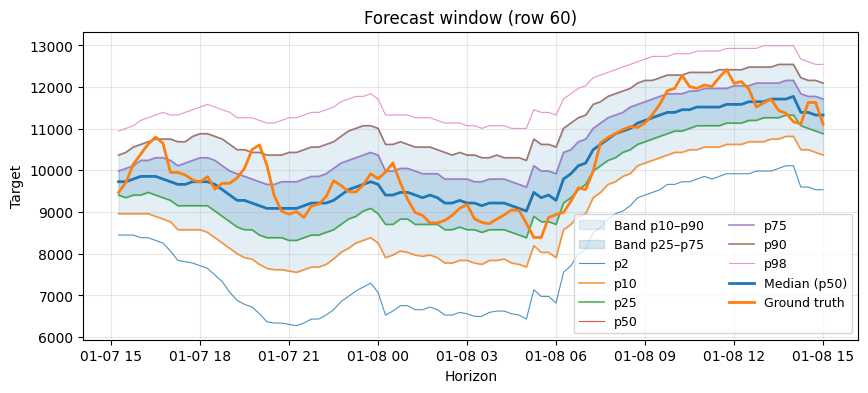

In [27]:
# 1) Validation timestamps
df_val = df_scaled[df_scaled["time_idx"] >= cutoff_idx + 1]
timestamps_val = df_val["date_time"].reset_index(drop=True)

# 2) Berechne num_windows
num_windows = len(timestamps_val) - max_encoder_length - max_prediction_length + 1

# 3) Window-Start timestamps
window_start_timestamps = timestamps_val.iloc[
    max_encoder_length : max_encoder_length + num_windows
].reset_index(drop=True)

# Beispielaufruf (wenn du bereits horizon_dt hast, nutze deine Variable):
x = 60
horizon_dt = make_horizon_dt_for_row(window_start_timestamps, x, H=y_true.shape[1], step_min=15)
plot_quantiles_vs_truth(q_pred, quants, y_true, horizon_dt, row=x)

##### 3.6.2.3 - visualize a single 24h window
**predict 96 steps ahead**

- now + 15 min
- now + 30 min
- ...
- now + 23 hours and 45 min

In [31]:
# 1) Validation timestamps
df_val = df_scaled[df_scaled["time_idx"] >= cutoff_idx + 1]
timestamps_val = df_val["date_time"].reset_index(drop=True)

# 2) Berechne num_windows
num_windows = len(timestamps_val) - max_encoder_length - max_prediction_length + 1

# 3) Window-Start timestamps
window_start_timestamps = timestamps_val.iloc[
    max_encoder_length : max_encoder_length + num_windows
].reset_index(drop=True)

# 4) Kürze y_pred/y_true

median_idx = quants.index(0.5)
y_pred = q_pred[:, :, median_idx]


y_pred_val = y_pred[:num_windows]
y_true_val = y_true[:num_windows]

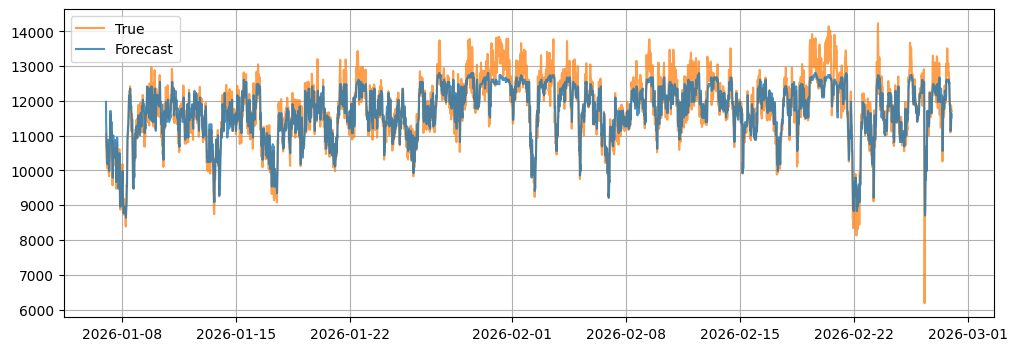

In [33]:
# 5) Horizon auswählen
h = 0  # t+15 min
pred_stream = y_pred_val[:, h]
true_stream = y_true_val[:, h]

# 6) Zielzeitstempel erstellen
horizon_dt = window_start_timestamps + pd.to_timedelta((h+1)*15, unit="min")

# 7) Plot
plt.figure(figsize=(12,4))
plt.plot(horizon_dt, true_stream, label="True", color="C1", alpha=0.75)
plt.plot(horizon_dt, pred_stream, label="Forecast", color="C0", alpha=0.8)
plt.legend()
plt.grid(True)
plt.show()

15 min ahead

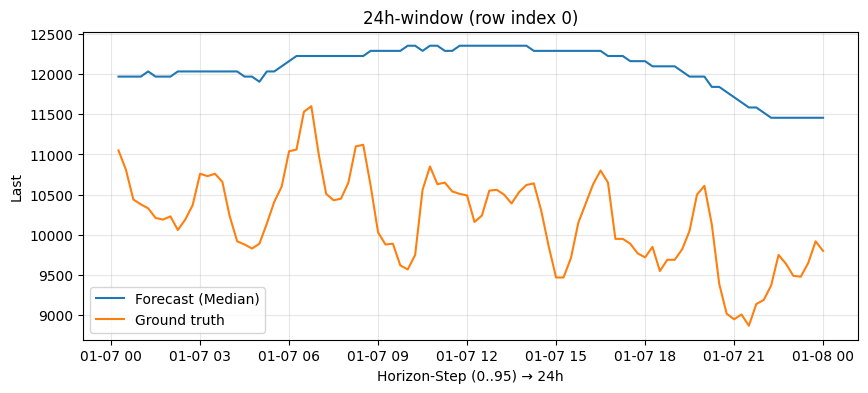

In [34]:
x = 0
pred_24h = y_pred_val[x, :]            # (96,)    alle Horizonte
true_24h = y_true_val[x, :]            # (96,)

horizon_dt = window_start_timestamps[x] \
             + pd.to_timedelta(np.arange(1,97)*15, unit="min")

plt.figure(figsize=(10,4))
plt.plot(horizon_dt, pred_24h, label="Forecast (Median)", color="C0")
plt.plot(horizon_dt, true_24h, label="Ground truth", color="C1")
plt.title(f"24h-window (row index {x})")
plt.xlabel("Horizon-Step (0..95) → 24h")
plt.ylabel("Last")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

30 min ahead

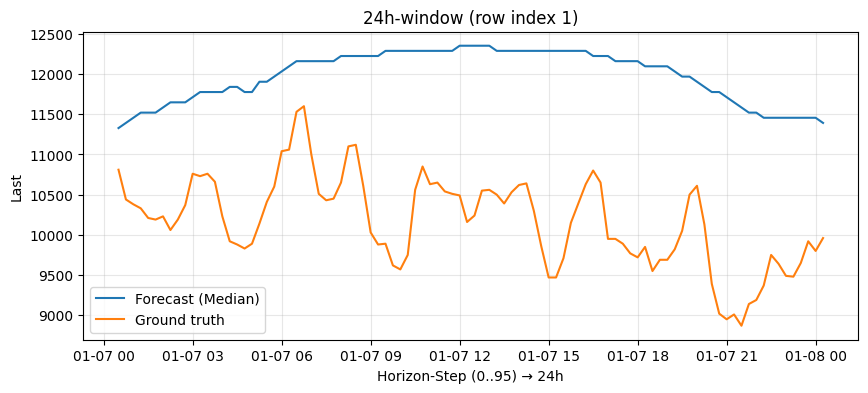

In [35]:
x = 1
pred_24h = y_pred_val[x, :]            # (96,)    alle Horizonte
true_24h = y_true_val[x, :]            # (96,)

horizon_dt = window_start_timestamps[x] \
             + pd.to_timedelta(np.arange(1,97)*15, unit="min")

plt.figure(figsize=(10,4))
plt.plot(horizon_dt, pred_24h, label="Forecast (Median)", color="C0")
plt.plot(horizon_dt, true_24h, label="Ground truth", color="C1")
plt.title(f"24h-window (row index {x})")
plt.xlabel("Horizon-Step (0..95) → 24h")
plt.ylabel("Last")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### 3.6.2.4 - rolling "Next-15-Minutes" 24-hour forecast

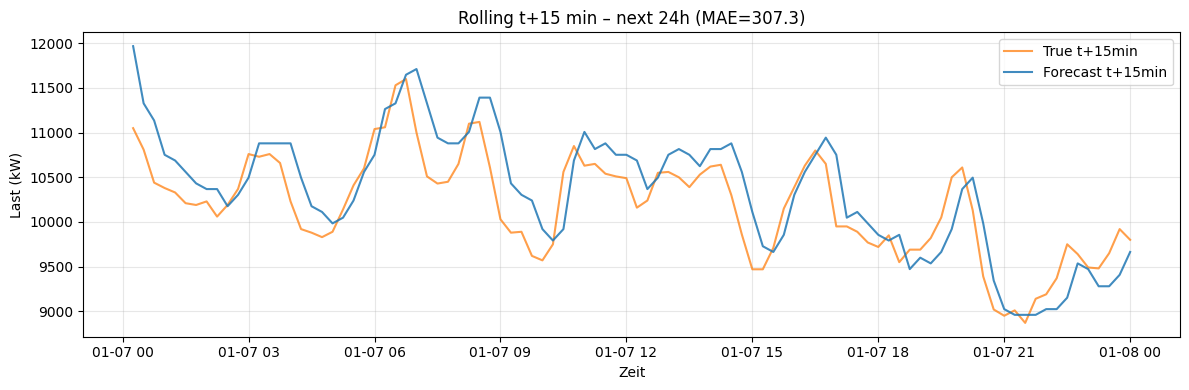

In [36]:
num_windows = len(timestamps_val) - max_encoder_length - max_prediction_length + 1
y_pred_val = y_pred[:num_windows]
y_true_val = y_true[:num_windows]

# Startzeitstempel der gültigen Sliding-Windows im Val-Bereich
window_start_timestamps = timestamps_val.iloc[
    max_encoder_length : max_encoder_length + num_windows
].reset_index(drop=True)

# --- Parameter für den gewünschten Horizont und Zeitraum ---
h = 0        # t+30 min (0=15, 1=30, 2=45, ...)
L = 96        # 96 Punkte = ~24h bei 15-min Takt
start_i = 0   # ab erstem verfügbaren Val-Fenster; bei Bedarf verschieben

# Streams und Zeitachse für die nächsten 24h extrahieren
pred_stream = y_pred_val[start_i:start_i+L, h]
true_stream = y_true_val[start_i:start_i+L, h]

# Zielzeitstempel = Fensterstart + (h+1)*15 Minuten
step_min = 15
horizon_dt = window_start_timestamps.iloc[start_i:start_i+L] + pd.to_timedelta((h+1)*step_min, unit="min")

# Sanity-Check: Längen müssen identisch sein
assert len(horizon_dt) == len(pred_stream) == len(true_stream) == L

# Metrik für genau diese 24h
mae_24h = float(np.mean(np.abs(pred_stream - true_stream)))

# Plot
plt.figure(figsize=(12,4))
plt.plot(horizon_dt, true_stream, label=f"True t+{(h+1)*step_min}min", color="C1", alpha=0.75)
plt.plot(horizon_dt, pred_stream, label=f"Forecast t+{(h+1)*step_min}min", color="C0", alpha=0.85)
plt.title(f"Rolling t+{(h+1)*step_min} min – next 24h (MAE={mae_24h:.1f})")
plt.xlabel("Zeit")
plt.ylabel("Last (kW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### 3.6.2.5 - rolling "Next-15/30-Minutes" 60 days forecast

15 min ahead

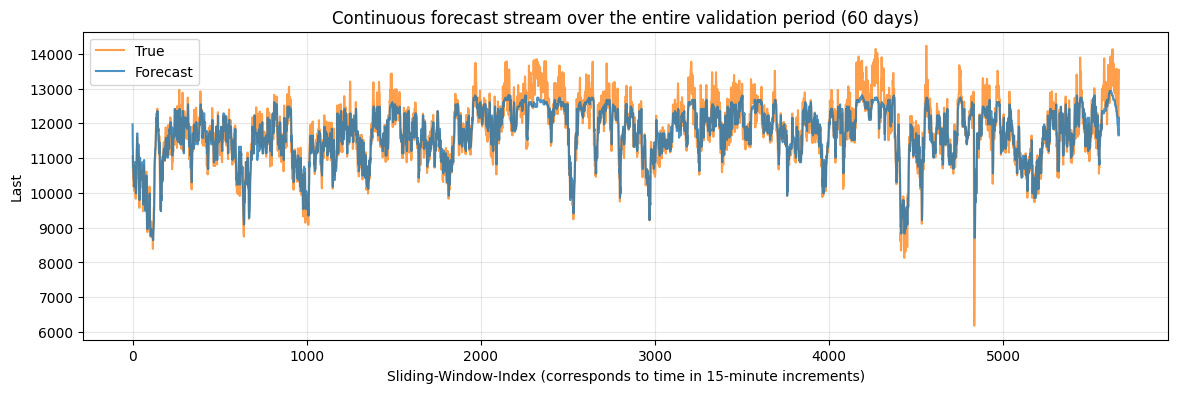

In [37]:
# Nimmt aus jedem Fenster nur den ersten Schritt (Horizon 0) → 15-min-Prognose-Stream
pred_stream = y_pred[:, 0]  # (N,)
true_stream = y_true[:, 0]  # (N,)

plt.figure(figsize=(14,4))
plt.plot(true_stream, label="True", color="C1", alpha=0.75)
plt.plot(pred_stream, label="Forecast", color="C0", alpha=0.8)
plt.title("Continuous forecast stream over the entire validation period (60 days)")
plt.xlabel("Sliding-Window-Index (corresponds to time in 15-minute increments)")
plt.ylabel("Last")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

30 min ahead

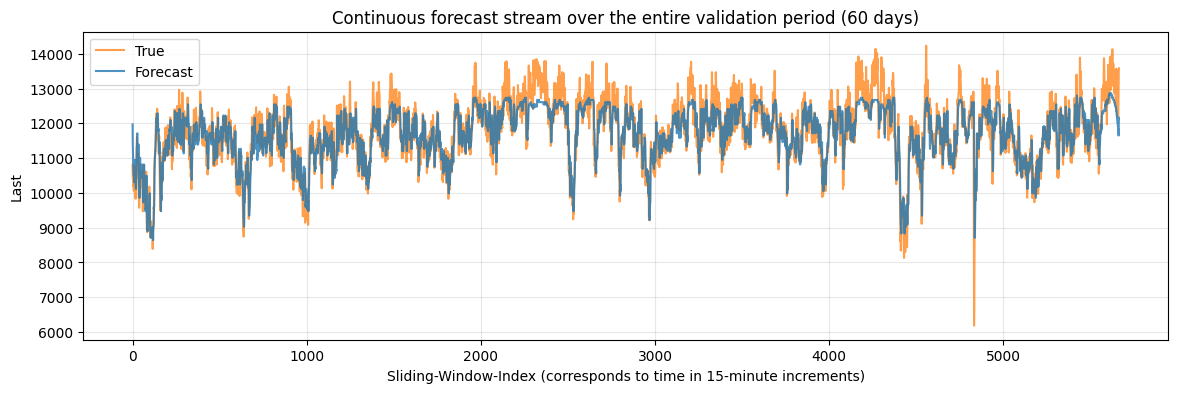

In [38]:
# Nimmt aus jedem Fenster nur den zweiten Schritt (Horizon 0) → 30-min-Prognose-Stream
pred_stream = y_pred[:, 1]  # (N,)
true_stream = y_true[:, 1]  # (N,)

plt.figure(figsize=(14,4))
plt.plot(true_stream, label="True", color="C1", alpha=0.75)
plt.plot(pred_stream, label="Forecast", color="C0", alpha=0.8)
plt.title("Continuous forecast stream over the entire validation period (60 days)")
plt.xlabel("Sliding-Window-Index (corresponds to time in 15-minute increments)")
plt.ylabel("Last")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### 3.6.3 - evaluation MAE/RMSE

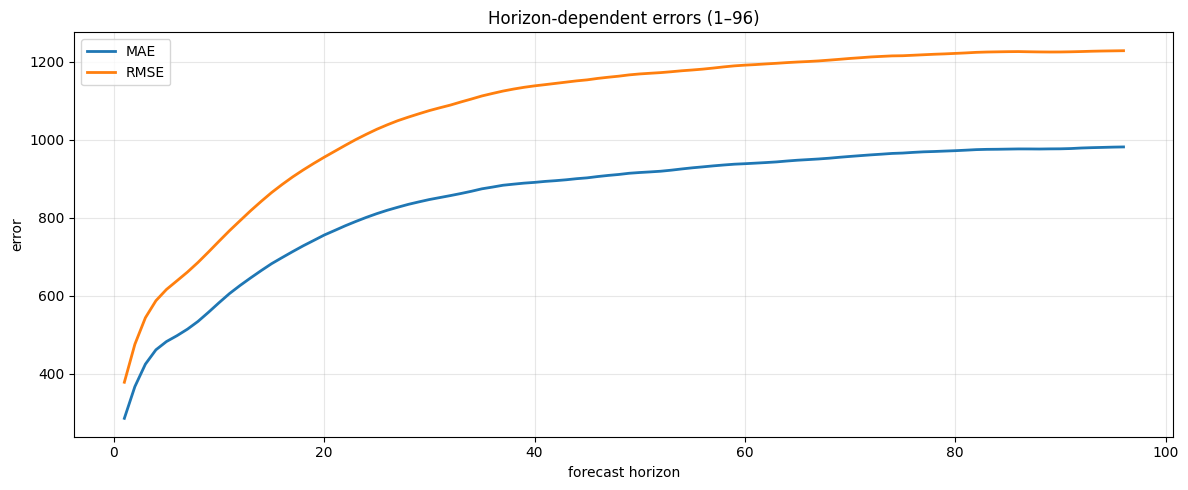

In [ ]:
# error for each horizon
hor_mae = np.mean(np.abs(y_pred - y_true), axis=0)
hor_rmse = np.sqrt(np.mean((y_pred - y_true)**2, axis=0))

H = hor_mae.shape[0]
x = np.arange(1, H+1)

plt.figure(figsize=(12, 5))
plt.plot(x, hor_mae, label="MAE", linewidth=2)
plt.plot(x, hor_rmse, label="RMSE", linewidth=2)

plt.title("Horizon-dependent errors (1–96)")
plt.xlabel("forecast horizon")
plt.ylabel("error")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### 3.7 - plot | true vs predicted

In [18]:
mae  = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred)
s    = smape(y_true, y_pred)
print(f"MAE: {mae:.4f} | RMSE: {rmse:.4f} | SMAPE: {s:.2f}%")

MAE: 752.4763 | RMSE: 924674.1875 | SMAPE: 6.48%


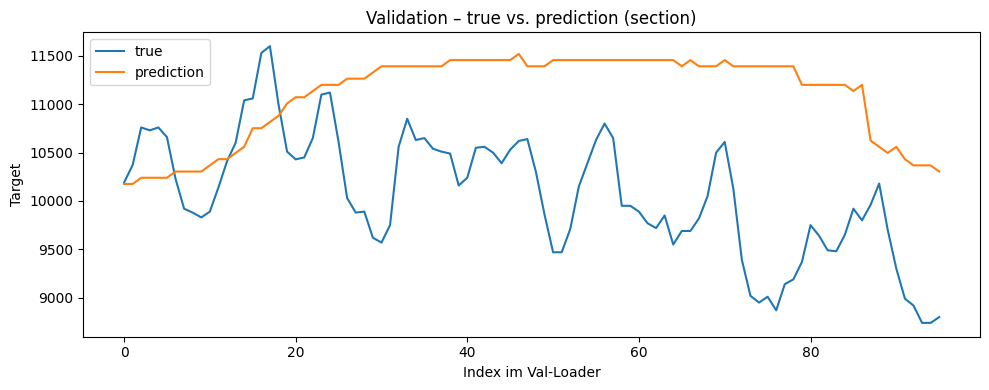

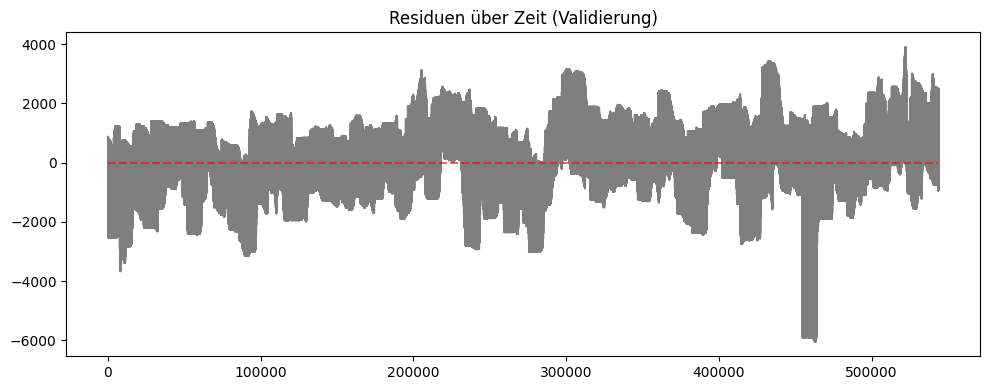

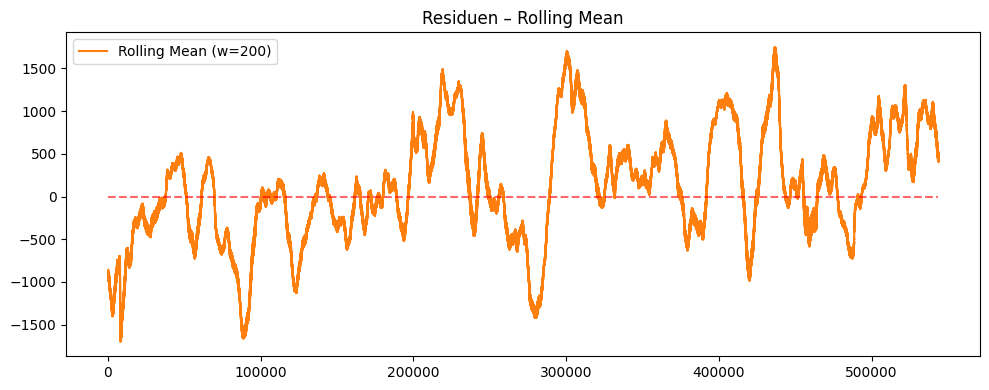

In [19]:
# true vs. prediction (section)
N = min(10, len(y_true)/96)
plt.figure(figsize=(10,4))
plt.plot(y_true[(N-1)*96:N*96], label="true")
plt.plot(y_pred[(N-1)*96:N*96], label="prediction")
# plt.plot(y_true[0:N*96], label="true")
# plt.plot(y_pred[0:N*96], label="prediction")
plt.title("Validation – true vs. prediction (section)")
plt.xlabel("Index im Val-Loader")
plt.ylabel("Target")
plt.legend()
plt.tight_layout()
plt.show()

# Residuen & Rolling-Mittel
residuals = y_true - y_pred

plt.figure(figsize=(10, 4))
plt.plot(residuals, color="tab:gray")
plt.hlines(0, 0, len(residuals), colors="r", linestyles="dashed", alpha=0.6)
plt.title("Residuen über Zeit (Validierung)")
plt.tight_layout()
plt.show()

window = 200
roll_mean = pd.Series(residuals).rolling(window).mean()
plt.figure(figsize=(10, 4))
plt.plot(roll_mean, color="tab:orange", label=f"Rolling Mean (w={window})")
plt.hlines(0, 0, len(roll_mean), colors="r", linestyles="dashed", alpha=0.6)
plt.title("Residuen – Rolling Mean")
plt.legend()
plt.tight_layout()
plt.show()